# 🛡️ ClaimShield AI — Cognizant Hackathon Model Pipeline

This notebook is a cleaned, leakage-safe version of the ClaimShield project.

### Models compared
1. SVM
2. CatBoost
3. AdaBoost
4. Random Forest
5. XGBoost
6. Tuned XGBoost

### Important
- `Fraud_Flag` is the training target.
- `Fraud_Risk_Score`, `Claim_Status`, and `Settlement_Amount` are treated as leakage/post-outcome fields and are excluded.
- `Claim_ID`, `Customer_ID`, and `Policy_Number` are identifiers and are excluded from the model.
- The supplied evaluation CSV is **unlabeled**, so it can receive predictions but cannot be scored with accuracy/PR-AUC until ground-truth labels are available.
- PR-AUC / Average Precision is the primary model-selection metric because fraud is an imbalanced classification problem.


In [1]:
# If running in Google Colab, uncomment:
!pip install -q catboost xgboost scikit-learn pandas numpy matplotlib seaborn joblib openpyxl

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
Libraries loaded successfully.


In [ ]:
# ============================================================
# 1. FILE PATHS
# ============================================================

# Training CSV from the original ClaimShield project.
# Change this only if your training file has a different name/path.
TRAIN_FILE = r"dataset/ClaimShieldAI-Dataset.csv"

# NEW unlabeled CSV supplied for the hackathon evaluation.
EVAL_FILE = r"dataset/evaluation_dataset_for_students_UNLABELED.csv"

if not os.path.exists(TRAIN_FILE):
    print(f"WARNING: Training file not found: {TRAIN_FILE}")
    print("Upload/copy ClaimShieldAI-Dataset.csv to the notebook runtime, then rerun this cell.")
else:
    print("Training file found:", TRAIN_FILE)

if not os.path.exists(EVAL_FILE):
    print(f"WARNING: Evaluation file not found: {EVAL_FILE}")
else:
    print("Evaluation file found:", EVAL_FILE)


Training file found: /content/ClaimShieldAI-Dataset.csv
Evaluation file found: /content/evaluation_dataset_for_students_UNLABELED.csv


In [3]:
# ============================================================
# 2. LOAD TRAINING DATA
# ============================================================

df = pd.read_csv(TRAIN_FILE)

print("Training shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Training shape: (40038, 16)


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Risk_Score,Fraud_Flag,Claim_Status,Settlement_Amount
0,CLM000001,CUST018311,POL0285346,79,Male,West,Home,3264.23,56380.37,8140.64,Accident,529,91.93,Yes,Under Review,4330.86
1,CLM000002,CUST003854,POL0518267,78,Female,West,Home,4937.85,98556.51,32997.15,Accident,331,82.90,Yes,Under Review,30106.34
2,CLM000003,CUST018067,POL0278802,57,Male,West,Health,3952.90,33481.54,14873.17,Property,642,30.69,No,Approved,10424.77
3,CLM000006,CUST004514,POL0823407,75,Female,East,Life,4680.15,38669.97,1783.29,Medical,342,47.91,No,Approved,1668.27
4,CLM000007,CUST015293,POL0112837,46,Female,West,Health,1886.92,72717.24,9550.18,Medical,528,40.18,No,Approved,8157.69



Columns:
['Claim_ID', 'Customer_ID', 'Policy_Number', 'Age', 'Gender', 'Region', 'Policy_Type', 'Premium_Amount', 'Coverage_Amount', 'Claim_Amount', 'Claim_Type', 'Credit_Score', 'Fraud_Risk_Score', 'Fraud_Flag', 'Claim_Status', 'Settlement_Amount']


In [5]:
# ============================================================
# 3. DATA VALIDATION + TARGET CREATION
# ============================================================

EXPECTED_TRAIN_COLUMNS = [
    "Claim_ID", "Customer_ID", "Policy_Number",
    "Age", "Gender", "Region", "Policy_Type",
    "Premium_Amount", "Coverage_Amount", "Claim_Amount",
    "Claim_Type", "Credit_Score",
    "Fraud_Risk_Score", "Fraud_Flag",
    "Claim_Status", "Settlement_Amount"
]

missing = [c for c in EXPECTED_TRAIN_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Training dataset is missing columns: {missing}")

df = df.copy()

# Normalize target safely.
if pd.api.types.is_numeric_dtype(df["Fraud_Flag"]):
    df["Target"] = pd.to_numeric(df["Fraud_Flag"], errors="coerce")
else:
    target_map = {
        "yes": 1, "y": 1, "true": 1, "fraud": 1, "fraudulent": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "genuine": 0, "0": 0
    }
    df["Target"] = (
        df["Fraud_Flag"].astype(str).str.strip().str.lower().map(target_map)
    )

if df["Target"].isna().any():
    raise ValueError("Fraud_Flag contains unexpected target values.")

df["Target"] = df["Target"].astype(int)

print("Rows:", len(df))
print("Fraud rate:", round(df["Target"].mean() * 100, 2), "%")
print("\nTarget distribution:")
display(df["Target"].value_counts().rename(index={0: "Genuine", 1: "Fraud"}))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))


Rows: 40038
Fraud rate: 24.82 %

Target distribution:


,count
Target,
Genuine,30102
Fraud,9936



Missing values:


,0
Claim_ID,0
Customer_ID,0
Policy_Number,0
Age,0
Gender,0
Region,0
Policy_Type,0
Premium_Amount,0
Coverage_Amount,0
Claim_Amount,0


In [6]:
# ============================================================
# 4. LEAKAGE CHECK
# ============================================================

LEAKAGE_COLUMNS = [
    "Fraud_Risk_Score",
    "Claim_Status",
    "Settlement_Amount",
    "Fraud_Flag"
]

IDENTIFIER_COLUMNS = [
    "Claim_ID",
    "Customer_ID",
    "Policy_Number"
]

print("Excluded leakage/post-outcome columns:")
for c in LEAKAGE_COLUMNS:
    print(" -", c)

print("\nExcluded identifier columns:")
for c in IDENTIFIER_COLUMNS:
    print(" -", c)

if "Fraud_Risk_Score" in df.columns:
    exact_rule_match = (
        ((pd.to_numeric(df["Fraud_Risk_Score"], errors="coerce") > 75).astype(int))
        == df["Target"]
    ).mean()
    print(f"\nFraud_Risk_Score > 75 target match: {exact_rule_match:.2%}")

print("\nThese columns will NOT enter any production model.")


Excluded leakage/post-outcome columns:
 - Fraud_Risk_Score
 - Claim_Status
 - Settlement_Amount
 - Fraud_Flag

Excluded identifier columns:
 - Claim_ID
 - Customer_ID
 - Policy_Number

Fraud_Risk_Score > 75 target match: 100.00%

These columns will NOT enter any production model.


In [7]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    x = data.copy()

    # Numeric conversion for robust arithmetic.
    numeric_cols = [
        "Age", "Premium_Amount", "Coverage_Amount",
        "Claim_Amount", "Credit_Score"
    ]
    for col in numeric_cols:
        if col in x.columns:
            x[col] = pd.to_numeric(x[col], errors="coerce")

    premium = x["Premium_Amount"].replace(0, np.nan)
    coverage = x["Coverage_Amount"].replace(0, np.nan)
    combined_limit = (
        x["Coverage_Amount"] + x["Premium_Amount"]
    ).replace(0, np.nan)

    x["Claim_Coverage_Ratio"] = x["Claim_Amount"] / coverage
    x["Claim_Premium_Ratio"] = x["Claim_Amount"] / premium
    x["Coverage_Premium_Ratio"] = x["Coverage_Amount"] / premium
    x["Remaining_Coverage"] = x["Coverage_Amount"] - x["Claim_Amount"]
    x["Claim_to_Combined_Limit"] = x["Claim_Amount"] / combined_limit

    x["Age_Credit_Interaction"] = x["Age"] * x["Credit_Score"]

    x["Young_Customer"] = (x["Age"] < 30).astype(int)
    x["Senior_Customer"] = (x["Age"] >= 60).astype(int)
    x["Low_Credit_Score"] = (x["Credit_Score"] < 600).astype(int)

    # Quantile-based flag is learned from training data later for production.
    # For reproducibility here, this is only a simple claim-size indicator.
    x["High_Claim"] = (x["Claim_Amount"] >= 100000).astype(int)

    x.replace([np.inf, -np.inf], np.nan, inplace=True)
    return x

model_df = engineer_features(df)

BASE_FEATURES = [
    "Age", "Gender", "Region", "Policy_Type",
    "Premium_Amount", "Coverage_Amount", "Claim_Amount",
    "Claim_Type", "Credit_Score"
]

ENGINEERED_FEATURES = [
    "Claim_Coverage_Ratio",
    "Claim_Premium_Ratio",
    "Coverage_Premium_Ratio",
    "Remaining_Coverage",
    "Claim_to_Combined_Limit",
    "Age_Credit_Interaction",
    "Young_Customer",
    "Senior_Customer",
    "Low_Credit_Score",
    "High_Claim"
]

FINAL_FEATURES = BASE_FEATURES + ENGINEERED_FEATURES

FORBIDDEN = set(LEAKAGE_COLUMNS + IDENTIFIER_COLUMNS)
bad_features = [c for c in FINAL_FEATURES if c in FORBIDDEN]

if bad_features:
    raise ValueError(f"Leakage/identifier feature detected: {bad_features}")

X = model_df[FINAL_FEATURES].copy()
y = model_df["Target"].copy()

print("Number of model features:", len(FINAL_FEATURES))
display(X.head())


Number of model features: 19


,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Claim_Coverage_Ratio,Claim_Premium_Ratio,Coverage_Premium_Ratio,Remaining_Coverage,Claim_to_Combined_Limit,Age_Credit_Interaction,Young_Customer,Senior_Customer,Low_Credit_Score,High_Claim
0,79,Male,West,Home,3264.23,56380.37,8140.64,Accident,529,0.144388,2.493893,17.272181,48239.73,0.136486,41791,0,1,1,0
1,78,Female,West,Home,4937.85,98556.51,32997.15,Accident,331,0.334804,6.682493,19.959397,65559.36,0.318830,25818,0,1,1,0
2,57,Male,West,Health,3952.90,33481.54,14873.17,Property,642,0.444220,3.762597,8.470121,18608.37,0.397312,36594,0,0,0,0
3,75,Female,East,Life,4680.15,38669.97,1783.29,Medical,342,0.046116,0.381033,8.262549,36886.68,0.041137,25650,0,1,1,0
4,46,Female,West,Health,1886.92,72717.24,9550.18,Medical,528,0.131333,5.061253,38.537532,63167.06,0.128011,24288,0,0,1,0


In [8]:
# ============================================================
# 6. TRAIN / UNTOUCHED TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print("Train:", X_train.shape)
print("Untouched test:", X_test.shape)
print("Training fraud rate:", round(y_train.mean() * 100, 2), "%")
print("scale_pos_weight:", round(scale_pos_weight, 4))


Train: (32030, 19)
Untouched test: (8008, 19)
Training fraud rate: 24.82 %
scale_pos_weight: 3.0294


In [9]:
# ============================================================
# 7. PREPROCESSORS
# ============================================================

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

NUMERIC_FEATURES = X_train.select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_FEATURES = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

TREE_PREPROCESSOR = ColumnTransformer([
    ("num", numeric_tree, NUMERIC_FEATURES),
    ("cat", categorical, CATEGORICAL_FEATURES)
])

SVM_PREPROCESSOR = ColumnTransformer([
    ("num", numeric_svm, NUMERIC_FEATURES),
    ("cat", categorical, CATEGORICAL_FEATURES)
])

print("Numeric:", NUMERIC_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)


Numeric: ['Age', 'Premium_Amount', 'Coverage_Amount', 'Claim_Amount', 'Credit_Score', 'Claim_Coverage_Ratio', 'Claim_Premium_Ratio', 'Coverage_Premium_Ratio', 'Remaining_Coverage', 'Claim_to_Combined_Limit', 'Age_Credit_Interaction', 'Young_Customer', 'Senior_Customer', 'Low_Credit_Score', 'High_Claim']
Categorical: ['Gender', 'Region', 'Policy_Type', 'Claim_Type']


In [10]:
# ============================================================
# 8. MODEL DEFINITIONS
# ============================================================

models = {
    "SVM": Pipeline([
        ("preprocessing", SVM_PREPROCESSOR),
        ("model", SVC(
            C=1.0,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "CatBoost": Pipeline([
        ("preprocessing", TREE_PREPROCESSOR),
        ("model", CatBoostClassifier(
            iterations=400,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="PRAUC",
            auto_class_weights="Balanced",
            verbose=False,
            random_seed=RANDOM_STATE,
            thread_count=-1,
            allow_writing_files=False
        ))
    ]),

    "AdaBoost": Pipeline([
        ("preprocessing", TREE_PREPROCESSOR),
        ("model", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                random_state=RANDOM_STATE
            ),
            n_estimators=300,
            learning_rate=0.03,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", TREE_PREPROCESSOR),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=16,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessing", TREE_PREPROCESSOR),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.90,
            reg_alpha=0.10,
            reg_lambda=2.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

print("Models ready:", list(models))


Models ready: ['SVM', 'CatBoost', 'AdaBoost', 'Random Forest', 'XGBoost']


In [11]:
# ============================================================
# 9. METRIC FUNCTION
# ============================================================

def get_metrics(y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "F2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "PR_AUC": average_precision_score(y_true, probability)
    }

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    metrics = get_metrics(y_test, prob)
    return model, prob, metrics

print("Metric function ready.")


Metric function ready.


In [12]:
# ============================================================
# 10. TRAIN SVM / CATBOOST / ADABOOST / RANDOM FOREST / XGBOOST
# ============================================================

results = []
fitted_models = {}
test_probabilities = {}

for name, model in models.items():
    print(f"Training {name} ...")
    fitted, prob, metrics = evaluate_model(name, model)

    fitted_models[name] = fitted
    test_probabilities[name] = prob

    results.append({
        "Model": name,
        **metrics
    })

comparison = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)

print("\nModel comparison on the untouched test set:")
display(comparison.round(4))


Training SVM ...
Training CatBoost ...
Training AdaBoost ...
Training Random Forest ...
Training XGBoost ...

Model comparison on the untouched test set:


,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
3,Random Forest,0.7328,0.3083,0.0619,0.1031,0.0737,0.5156,0.2650
4,XGBoost,0.5789,0.2549,0.3624,0.2993,0.3342,0.5161,0.2619
0,SVM,0.7519,0.0000,0.0000,0.0000,0.0000,0.5223,0.2580
2,AdaBoost,0.7519,0.0000,0.0000,0.0000,0.0000,0.5075,0.2552
1,CatBoost,0.5523,0.2531,0.4122,0.3136,0.3661,0.5105,0.2534


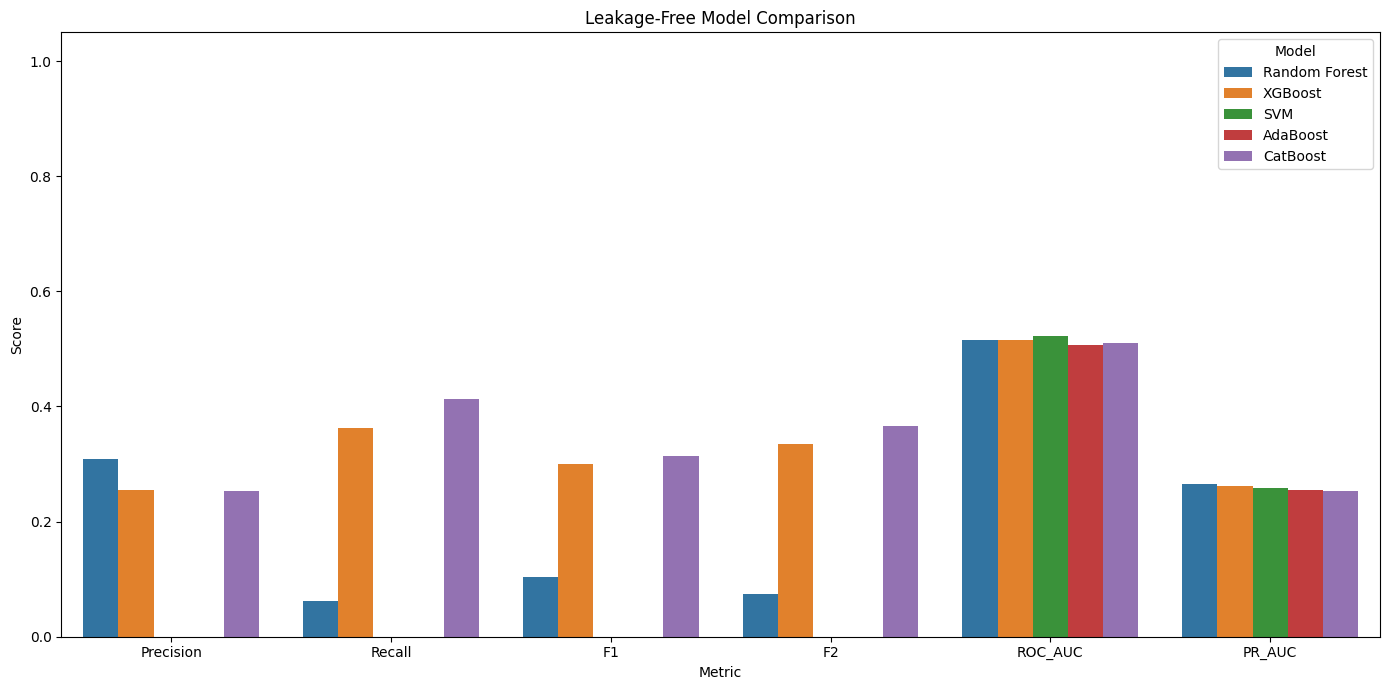

In [13]:
# ============================================================
# 11. VISUAL MODEL COMPARISON
# ============================================================

plot_df = comparison.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1", "F2", "ROC_AUC", "PR_AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Leakage-Free Model Comparison")
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 12. TUNED XGBOOST — OPTIMIZE AVERAGE PRECISION / PR-AUC
# ============================================================

tuned_xgb = Pipeline([
    ("preprocessing", TREE_PREPROCESSOR),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [250, 350, 500, 700],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.75, 0.85, 0.95, 1.0],
    "model__colsample_bytree": [0.75, 0.85, 0.90, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5, 1],
    "model__reg_lambda": [1, 2, 5, 10]
}

tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

random_search = RandomizedSearchCV(
    estimator=tuned_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)
print("\nBest CV PR-AUC:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'model__subsample': 0.85, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 250, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.75}

Best CV PR-AUC: 0.25772080830681776


In [15]:
# ============================================================
# 13. EVALUATE TUNED XGBOOST ON UNTOUCHED TEST
# ============================================================

tuned_model = random_search.best_estimator_
tuned_test_probability = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = get_metrics(y_test, tuned_test_probability)

tuned_row = pd.DataFrame([{
    "Model": "Tuned XGBoost",
    **tuned_metrics
}])

comparison_with_tuned = pd.concat(
    [comparison, tuned_row],
    ignore_index=True
).sort_values("PR_AUC", ascending=False)

display(comparison_with_tuned.round(4))


,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,Random Forest,0.7328,0.3083,0.0619,0.1031,0.0737,0.5156,0.2650
1,XGBoost,0.5789,0.2549,0.3624,0.2993,0.3342,0.5161,0.2619
5,Tuned XGBoost,0.5154,0.2558,0.4992,0.3383,0.4194,0.5156,0.2592
2,SVM,0.7519,0.0000,0.0000,0.0000,0.0000,0.5223,0.2580
3,AdaBoost,0.7519,0.0000,0.0000,0.0000,0.0000,0.5075,0.2552
4,CatBoost,0.5523,0.2531,0.4122,0.3136,0.3661,0.5105,0.2534


In [16]:
# ============================================================
# 14. SELECT OPERATING THRESHOLD FROM TRAINING DATA ONLY
# ============================================================

# Threshold selection must NOT use the untouched test labels.
# We generate out-of-fold predictions on X_train only.

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_train_probability = cross_val_predict(
    tuned_model,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.005):
    pred = (oof_train_probability >= threshold).astype(int)
    flag_rate = pred.mean()

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, pred, zero_division=0),
        "Recall": recall_score(y_train, pred, zero_division=0),
        "F1": f1_score(y_train, pred, zero_division=0),
        "F2": fbeta_score(y_train, pred, beta=2, zero_division=0),
        "Flag_Rate": flag_rate
    })

threshold_df = pd.DataFrame(threshold_rows)

# Business constraint: do not automatically flag more than 40% of claims.
eligible = threshold_df[threshold_df["Flag_Rate"] <= 0.40]

if eligible.empty:
    selected_threshold = 0.50
else:
    selected_threshold = float(
        eligible.loc[eligible["F2"].idxmax(), "Threshold"]
    )

print("Selected operating threshold:", round(selected_threshold, 3))
display(
    threshold_df.loc[
        (threshold_df["Threshold"] - selected_threshold).abs().argsort()[:1]
    ].round(4)
)


Selected operating threshold: 0.505


,Threshold,Precision,Recall,F1,F2,Flag_Rate
81,0.505,0.2533,0.367,0.2997,0.3368,0.3595


In [17]:
# ============================================================
# 15. FINAL TEST METRICS AT BUSINESS THRESHOLD
# ============================================================

final_test_pred = (tuned_test_probability >= selected_threshold).astype(int)

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, final_test_pred),
    "Precision": precision_score(y_test, final_test_pred, zero_division=0),
    "Recall": recall_score(y_test, final_test_pred, zero_division=0),
    "F1": f1_score(y_test, final_test_pred, zero_division=0),
    "F2": fbeta_score(y_test, final_test_pred, beta=2, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, tuned_test_probability),
    "PR_AUC": average_precision_score(y_test, tuned_test_probability),
    "Flag_Rate": final_test_pred.mean()
}

print("FINAL TUNED XGBOOST TEST METRICS")
display(pd.DataFrame([final_test_metrics]).round(4))

print("\nClassification report:")
print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    )
)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_test_pred))


FINAL TUNED XGBOOST TEST METRICS


,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,Flag_Rate
0,0.5822,0.2595,0.3689,0.3047,0.3402,0.5156,0.2592,0.3528



Classification report:
              precision    recall  f1-score   support

     Genuine       0.76      0.65      0.70      6021
       Fraud       0.26      0.37      0.30      1987

    accuracy                           0.58      8008
   macro avg       0.51      0.51      0.50      8008
weighted avg       0.63      0.58      0.60      8008


Confusion matrix:
[[3929 2092]
 [1254  733]]


In [18]:
# ============================================================
# 16. RETRAIN FINAL TUNED XGBOOST ON ALL LABELED TRAINING DATA
# ============================================================

final_model = random_search.best_estimator_
final_model.fit(X, y)

print("Final production model trained on all labeled training data.")


Final production model trained on all labeled training data.


,Feature,Importance
12,num__Senior_Customer,0.051850
22,cat__Policy_Type_Health,0.050931
5,num__Claim_Coverage_Ratio,0.050389
1,num__Premium_Amount,0.048745
9,num__Claim_to_Combined_Limit,0.047367
8,num__Remaining_Coverage,0.047132
0,num__Age,0.047074
7,num__Coverage_Premium_Ratio,0.046994
10,num__Age_Credit_Interaction,0.045500
23,cat__Policy_Type_Home,0.044727


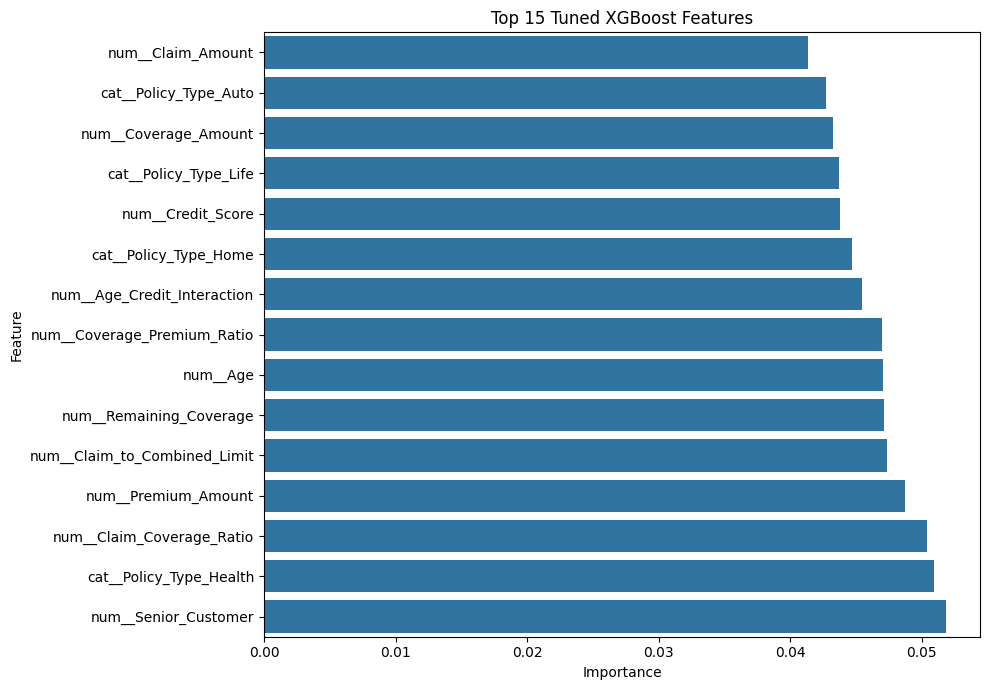

In [19]:
# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

preprocessor_fitted = final_model.named_steps["preprocessing"]
xgb_fitted = final_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importance = xgb_fitted.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top = importance_df.head(15).sort_values("Importance")
sns.barplot(data=top, x="Importance", y="Feature")
plt.title("Top 15 Tuned XGBoost Features")
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 18. SAVE MODEL ARTIFACTS
# ============================================================

MODEL_FILE = "claimshield_cognizant_tuned_xgboost.pkl"
THRESHOLD_FILE = "claimshield_cognizant_threshold.pkl"
FEATURES_FILE = "claimshield_cognizant_features.pkl"

joblib.dump(final_model, MODEL_FILE)
joblib.dump(selected_threshold, THRESHOLD_FILE)
joblib.dump(FINAL_FEATURES, FEATURES_FILE)

print("Saved:")
print(" -", MODEL_FILE)
print(" -", THRESHOLD_FILE)
print(" -", FEATURES_FILE)


Saved:
 - claimshield_cognizant_tuned_xgboost.pkl
 - claimshield_cognizant_threshold.pkl
 - claimshield_cognizant_features.pkl


In [21]:
# ============================================================
# 19. LOAD NEW UNLABELED EVALUATION CSV
# ============================================================

evaluation_df = pd.read_csv(EVAL_FILE)

print("Evaluation shape:", evaluation_df.shape)
display(evaluation_df.head())

EXPECTED_EVAL_COLUMNS = [
    "Claim_ID", "Customer_ID", "Policy_Number",
    "Age", "Gender", "Region", "Policy_Type",
    "Premium_Amount", "Coverage_Amount", "Claim_Amount",
    "Claim_Type", "Credit_Score"
]

missing_eval = [
    c for c in EXPECTED_EVAL_COLUMNS
    if c not in evaluation_df.columns
]

if missing_eval:
    raise ValueError(f"Evaluation CSV is missing required columns: {missing_eval}")

print("\nEvaluation columns validated.")


Evaluation shape: (9962, 12)


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score
0,CLM000004,CUST007487,POL0372362,66,Male,North,Health,579.12,24701.69,616.78,Property,411
1,CLM000005,CUST011899,POL0882135,21,Female,East,Home,676.23,28416.22,42049.70,Theft,714
2,CLM000009,CUST005436,POL0133206,35,Female,East,Auto,2771.01,32348.61,5396.93,Accident,477
3,CLM000011,CUST015611,POL0872204,47,Female,North,Health,2703.14,38434.95,34641.34,Theft,706
4,CLM000021,CUST014423,POL0583144,66,Male,North,Home,1362.16,95756.10,49643.10,Accident,827



Evaluation columns validated.


In [22]:
# ============================================================
# 20. APPLY EXACT SAME FEATURE ENGINEERING TO NEW CSV
# ============================================================

evaluation_features = engineer_features(
    evaluation_df[EXPECTED_EVAL_COLUMNS].copy()
)

evaluation_X = evaluation_features[FINAL_FEATURES].copy()

print("Evaluation model matrix:", evaluation_X.shape)
print("Feature mismatch check:")
print("Missing:", [c for c in FINAL_FEATURES if c not in evaluation_X.columns])
print("Extra:", [c for c in evaluation_X.columns if c not in FINAL_FEATURES])


Evaluation model matrix: (9962, 19)
Feature mismatch check:
Missing: []
Extra: []


In [29]:
# ============================================================
# 21. PREDICT NEW UNLABELED DATA
# ============================================================

evaluation_probability = final_model.predict_proba(evaluation_X)[:, 1]
evaluation_prediction = (
    evaluation_probability >= selected_threshold
).astype(int)

def risk_level(prob):
    if prob < 0.50:
        return "LOW"
    if prob < 0.70:
        return "MEDIUM"
    if prob < 0.90:
        return "HIGH"
    return "CRITICAL"

def recommended_action(prob):
    if prob < 0.30:
        return "APPROVE"
    if prob < selected_threshold:
        return "REVIEW"
    return "INVESTIGATE"

results_eval = evaluation_df.copy()

results_eval["Fraud_Probability"] = evaluation_probability
results_eval["Fraud_Risk_Score"] = np.clip(
    evaluation_probability * 100, 0, 100
)
results_eval["Fraud_Prediction"] = np.where(
    evaluation_prediction == 1,
    "Fraudulent",
    "Genuine"
)
results_eval["Risk_Level"] = [
    risk_level(p) for p in evaluation_probability
]
results_eval["Recommended_Action"] = [
    recommended_action(p) for p in evaluation_probability
]
results_eval["Potential_Financial_Loss"] = (
    evaluation_probability
    * pd.to_numeric(results_eval["Claim_Amount"], errors="coerce").fillna(0)
)

print("Predictions generated for", len(results_eval), "claims.")
display(
    results_eval.sort_values(
        "Fraud_Probability",
        ascending=False
    ).head(20).round(4)
)


Predictions generated for 9962 claims.


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Probability,Fraud_Risk_Score,Fraud_Prediction,Risk_Level,Recommended_Action,Potential_Financial_Loss
3448,CLM016930,CUST012218,POL0118199,27,Female,South,Life,3105.42,24263.01,49521.76,Theft,725,0.5666,56.656700,Fraudulent,MEDIUM,INVESTIGATE,28057.3804
9262,CLM046547,CUST006948,POL0838186,21,Male,South,Home,3677.32,57178.16,4758.02,Property,842,0.5655,56.547901,Fraudulent,MEDIUM,INVESTIGATE,2690.5617
3032,CLM014959,CUST003788,POL0474646,34,Female,West,Auto,1466.21,38137.62,49548.10,Theft,749,0.5648,56.480999,Fraudulent,MEDIUM,INVESTIGATE,27985.2376
2277,CLM011203,CUST016754,POL0752662,21,Male,South,Auto,2373.92,79627.80,49487.00,Theft,679,0.5627,56.266800,Fraudulent,MEDIUM,INVESTIGATE,27844.7614
9541,CLM047914,CUST014214,POL0810062,30,Male,South,Auto,2231.20,43461.76,15994.32,Accident,846,0.5621,56.208302,Fraudulent,MEDIUM,INVESTIGATE,8990.1374
88,CLM000417,CUST001330,POL0695699,22,Female,West,Life,312.03,99716.94,847.27,Property,558,0.5618,56.182301,Fraudulent,MEDIUM,INVESTIGATE,476.0156
1514,CLM007407,CUST016751,POL0624469,31,Male,South,Home,4424.89,53899.39,37770.05,Medical,844,0.5617,56.173100,Fraudulent,MEDIUM,INVESTIGATE,21216.6252
9433,CLM047388,CUST000318,POL0360083,22,Male,West,Home,3733.16,53302.28,16274.14,Theft,849,0.5615,56.150799,Fraudulent,MEDIUM,INVESTIGATE,9138.0666
2070,CLM010107,CUST012762,POL0265605,31,Male,East,Life,3610.79,42115.72,15510.43,Theft,848,0.5614,56.137501,Fraudulent,MEDIUM,INVESTIGATE,8707.1689
9386,CLM047151,CUST015819,POL0274662,31,Male,East,Home,1669.28,26094.01,8146.45,Property,849,0.5597,55.974201,Fraudulent,MEDIUM,INVESTIGATE,4559.9144


In [30]:
print('Distribution of Risk Levels:')
display(results_eval['Risk_Level'].value_counts())

print('\nAverage Fraud Probability by Risk Level:')
display(results_eval.groupby('Risk_Level')['Fraud_Probability'].mean().sort_values(ascending=False).round(4))

Distribution of Risk Levels:


,count
Risk_Level,
LOW,5018
MEDIUM,4944



Average Fraud Probability by Risk Level:


,Fraud_Probability
Risk_Level,
MEDIUM,0.5117
LOW,0.4868


In [32]:
print(results_eval["Fraud_Probability"].describe())

print("\nDecision distribution:")
print(results_eval["Recommended_Action"].value_counts())

print("\nRisk distribution:")
print(results_eval["Risk_Level"].value_counts())

count    9962.000000
mean        0.499178
std         0.016789
min         0.398498
25%         0.490253
50%         0.499845
75%         0.509764
max         0.566567
Name: Fraud_Probability, dtype: float64

Decision distribution:
Recommended_Action
REVIEW         6385
INVESTIGATE    3577
Name: count, dtype: int64

Risk distribution:
Risk_Level
LOW       5018
MEDIUM    4944
Name: count, dtype: int64


In [33]:
print("Minimum probability:", results_eval["Fraud_Probability"].min())
print("Maximum probability:", results_eval["Fraud_Probability"].max())
print("Below 0.20:", (results_eval["Fraud_Probability"] < 0.20).sum())
print("Below 0.30:", (results_eval["Fraud_Probability"] < 0.30).sum())
print("Below 0.50:", (results_eval["Fraud_Probability"] < 0.50).sum())

Minimum probability: 0.39849764108657837
Maximum probability: 0.5665667057037354
Below 0.20: 0
Below 0.30: 0
Below 0.50: 5018


In [34]:
print("Target distribution:")
print(y.value_counts(normalize=True))

print("\nFraud rate:")
print(y.mean())

print("\nFeature correlation with target:")
corr = model_df.select_dtypes(include=np.number).corr()["Target"]
print(corr.sort_values(ascending=False))

Target distribution:
Target
0    0.751836
1    0.248164
Name: proportion, dtype: float64

Fraud rate:
0.24816424396823017

Feature correlation with target:
Target                     1.000000
Fraud_Risk_Score           0.749460
Coverage_Amount            0.009493
Remaining_Coverage         0.008405
Credit_Score               0.007251
Young_Customer             0.007101
Premium_Amount             0.003751
Settlement_Amount          0.003452
Claim_Amount              -0.000045
Coverage_Premium_Ratio    -0.002319
Low_Credit_Score          -0.004160
Claim_Coverage_Ratio      -0.006075
Claim_to_Combined_Limit   -0.006286
Claim_Premium_Ratio       -0.008477
Age_Credit_Interaction    -0.010249
Age                       -0.015674
Senior_Customer           -0.017209
High_Claim                      NaN
Name: Target, dtype: float64


In [35]:
print("\nFraud vs Genuine averages:")

comparison = model_df.groupby("Target")[
    [
        "Age",
        "Premium_Amount",
        "Coverage_Amount",
        "Claim_Amount",
        "Credit_Score",
        "Claim_Coverage_Ratio",
        "Claim_Premium_Ratio"
    ]
].mean()

display(comparison)


Fraud vs Genuine averages:


,Age,Premium_Amount,Coverage_Amount,Claim_Amount,Credit_Score,Claim_Coverage_Ratio,Claim_Premium_Ratio
Target,,,,,,,
0,48.742243,2598.259039,52601.338203,25128.323607,575.114943,0.795534,16.922339
1,48.092895,2610.313120,53205.865462,25126.830827,577.790660,0.781073,16.461490


In [36]:
categorical_cols = [
    "Gender",
    "Region",
    "Policy_Type",
    "Claim_Type"
]

for col in categorical_cols:
    print("\n" + "=" * 60)
    print(col)

    temp = (
        model_df.groupby(col)["Target"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    temp["Fraud_Rate_%"] = temp["mean"] * 100
    display(temp)


Gender


,count,mean,Fraud_Rate_%
Gender,,,
Female,19904,0.250151,25.015072
Male,20134,0.246200,24.620046



Region


,count,mean,Fraud_Rate_%
Region,,,
South,9998,0.254551,25.455091
East,10122,0.250642,25.064217
West,9947,0.244395,24.439530
North,9971,0.243005,24.300471



Policy_Type


,count,mean,Fraud_Rate_%
Policy_Type,,,
Home,10010,0.255445,25.544456
Auto,10067,0.252906,25.290553
Life,10040,0.248705,24.870518
Health,9921,0.235460,23.546014



Claim_Type


,count,mean,Fraud_Rate_%
Claim_Type,,,
Theft,10172,0.254031,25.403067
Accident,9987,0.251627,25.162712
Property,9923,0.246800,24.680036
Medical,9956,0.240056,24.005625


In [31]:
# ============================================================
# 22. HACKATHON BUSINESS DASHBOARD SUMMARY
# ============================================================

total_claims = len(results_eval)
fraudulent = int((results_eval["Fraud_Prediction"] == "Fraudulent").sum())
genuine = total_claims - fraudulent

approve = int((results_eval["Recommended_Action"] == "APPROVE").sum())
review = int((results_eval["Recommended_Action"] == "REVIEW").sum())
investigate = int((results_eval["Recommended_Action"] == "INVESTIGATE").sum())

total_exposure = results_eval["Potential_Financial_Loss"].sum()

print("=" * 65)
print("                 CLAIMSHIELD AI")
print("            COGNIZANT HACKATHON")
print("=" * 65)
print(f"Total claims analyzed       : {total_claims:,}")
print(f"Fraudulent predictions      : {fraudulent:,}")
print(f"Genuine predictions         : {genuine:,}")
print(f"Approve                     : {approve:,}")
print(f"Review                      : {review:,}")
print(f"Investigate                 : {investigate:,}")
print(f"Estimated financial exposure: ₹{total_exposure:,.2f}")
print(f"Operating threshold         : {selected_threshold:.3f}")
print("=" * 65)

print("\nImportant: the evaluation CSV is unlabeled, so these are predictions,")
print("not measured fraud outcomes.")


                 CLAIMSHIELD AI
            COGNIZANT HACKATHON
Total claims analyzed       : 9,962
Fraudulent predictions      : 3,577
Genuine predictions         : 6,385
Approve                     : 0
Review                      : 6,385
Investigate                 : 3,577
Estimated financial exposure: ₹123,795,829.67
Operating threshold         : 0.505

Important: the evaluation CSV is unlabeled, so these are predictions,
not measured fraud outcomes.


In [25]:
# ============================================================
# 23. EXPORT FINAL HACKATHON PREDICTIONS
# ============================================================

OUTPUT_FILE = "ClaimShield_Cognizant_Evaluation_Predictions.csv"

results_eval.to_csv(
    OUTPUT_FILE,
    index=False
)

print("Prediction file exported:", OUTPUT_FILE)
display(results_eval.head())


Prediction file exported: ClaimShield_Cognizant_Evaluation_Predictions.csv


,Claim_ID,Customer_ID,Policy_Number,Age,Gender,Region,Policy_Type,Premium_Amount,Coverage_Amount,Claim_Amount,Claim_Type,Credit_Score,Fraud_Probability,Fraud_Risk_Score,Fraud_Prediction,Risk_Level,Recommended_Action,Potential_Financial_Loss
0,CLM000004,CUST007487,POL0372362,66,Male,North,Health,579.12,24701.69,616.78,Property,411,0.470525,47.052540,Genuine,MEDIUM,REVIEW,290.210665
1,CLM000005,CUST011899,POL0882135,21,Female,East,Home,676.23,28416.22,42049.70,Theft,714,0.506685,50.668461,Fraudulent,MEDIUM,INVESTIGATE,21305.935480
2,CLM000009,CUST005436,POL0133206,35,Female,East,Auto,2771.01,32348.61,5396.93,Accident,477,0.514709,51.470947,Fraudulent,MEDIUM,INVESTIGATE,2777.850994
3,CLM000011,CUST015611,POL0872204,47,Female,North,Health,2703.14,38434.95,34641.34,Theft,706,0.485653,48.565342,Genuine,MEDIUM,REVIEW,16823.685599
4,CLM000021,CUST014423,POL0583144,66,Male,North,Home,1362.16,95756.10,49643.10,Accident,827,0.496158,49.615829,Genuine,MEDIUM,REVIEW,24630.836194


In [26]:
# ============================================================
# 24. FINAL MODEL COMPARISON FOR PRESENTATION
# ============================================================

presentation_table = comparison_with_tuned.copy()

presentation_table["PR_AUC"] = presentation_table["PR_AUC"].round(4)
presentation_table["ROC_AUC"] = presentation_table["ROC_AUC"].round(4)
presentation_table["Precision"] = presentation_table["Precision"].round(4)
presentation_table["Recall"] = presentation_table["Recall"].round(4)
presentation_table["F1"] = presentation_table["F1"].round(4)
presentation_table["F2"] = presentation_table["F2"].round(4)

presentation_table = presentation_table.sort_values(
    "PR_AUC",
    ascending=False
)

display(presentation_table)

print("\nRecommended presentation message:")
print(
    "Select the model using PR-AUC/Average Precision rather than accuracy alone. "
    "Use the tuned XGBoost if it gives the best PR-AUC on the untouched test set."
)


,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC
0,Random Forest,0.732767,0.3083,0.0619,0.1031,0.0737,0.5156,0.2650
1,XGBoost,0.578921,0.2549,0.3624,0.2993,0.3342,0.5161,0.2619
5,Tuned XGBoost,0.515360,0.2558,0.4992,0.3383,0.4194,0.5156,0.2592
2,SVM,0.751873,0.0000,0.0000,0.0000,0.0000,0.5223,0.2580
3,AdaBoost,0.751873,0.0000,0.0000,0.0000,0.0000,0.5075,0.2552
4,CatBoost,0.552323,0.2531,0.4122,0.3136,0.3661,0.5105,0.2534



Recommended presentation message:
Select the model using PR-AUC/Average Precision rather than accuracy alone. Use the tuned XGBoost if it gives the best PR-AUC on the untouched test set.
